In [1]:
import itertools as iter

import awkward as ak

import dask
import dask_awkward as dak
import hist.dask as hda
import matplotlib.pyplot as plt

# import numba
import numpy as np
import uproot

# import vector as vec
from coffea.analysis_tools import PackedSelection
from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
# from hist import Hist


/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
from coffea.lookup_tools import extractor

In [3]:
file_list = [line.strip('\n') for line in open("filelists/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] # + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[12:13]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

events = small_events[0:20_000]
#ak.num(small_events, axis=0).compute()

In [4]:
def apply_JEC_MC(ev, dir_name, name, type):
    ext = extractor()
    ext.add_weight_sets(
        [
            "* * corrections/" + dir_name + "/" + name + "_L1FastJet_AK4PF" + type + ".txt",
            # "* * corrections/" + dir_name + "/" + name + "_L2Residual_AK4PF" + type + ".txt",
            "* * corrections/" + dir_name + "/" + name + "_L2Relative_AK4PF" + type + ".txt",
            "* * corrections/" + dir_name + "/" + name + "_L3Absolute_AK4PF" + type + ".txt",
            "* * corrections/" + dir_name + "/" + name + "_L2L3Residual_AK4PF" + type + ".txt",
            #"* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi.junc.txt",
        ],
    )
    ext.finalize()


    jec_stack_names = [
        name + "_L1FastJet_AK4PF"+ type,
        name + "_L2Relative_AK4PF"+ type,
        # name + "_L2Residual_AK4PF"+ type,
        name + "_L3Absolute_AK4PF"+ type,
        # name + "_L2L3Residual_AK4PF"+ type,
        #"Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi",
    ]

    evaluator = ext.make_evaluator()

    corr_jets = ev.ScoutingJet
    corr_jets["pt_raw"] = corr_jets.pt

    for i in range(len(jec_stack_names)):
        scale_factor = evaluator[jec_stack_names[i]](corr_jets.eta, corr_jets.pt, events.ScoutingRho, corr_jets.area)
        corr_jets["pt"] = scale_factor*corr_jets.pt
        #corr_jets["e"] = scale_factor*corr_jets.e
    return corr_jets


In [6]:
events["ScoutingJet_corr_chs"] = apply_JEC_MC(events, "Winter22Run3_V2_MC","Winter22Run3_V2_MC", "Puppi")
events["ScoutingJet_corr_puppi"] = apply_JEC_MC(events, "Summer22EE_22Sep2023_V2_MC", "Summer22EE_22Sep2023_V2_MC","Puppi")
# events["ScoutingJet_corr_puppi_pr"] = apply_JEC_MC(events, "Summer22EE_22Sep2023_V2_MC","Summer22EE_22Sep2023_V2_MC", "PuppiPNetRegression")
events["ScoutingJet_corr_puppi_prn"] = apply_JEC_MC(events, "Summer22_22Sep2023_V2_MC", "Summer22_22Sep2023_V2_MC","Puppi")
events["ScoutingJet_corr_chs_2"] = apply_JEC_MC(events, "12_4_0_pre3","Run3Summer21_MC", "chsHLT")
events["ScoutingJet_corr_puppi_2"] = apply_JEC_MC(events, "12_4_0_pre3","Run3Summer21_MC", "PuppiHLT")
events["ScoutingJet_corr_clus"] = apply_JEC_MC(events, "12_4_0_pre3","Run3Summer21_MC", "ClusterHLT")

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/numpy/lib/npyio.py:2409: RuntimeWarning: overflow encountered in cast
  rows = np.array(data, dtype=[('', _) for _ in dtype_flat])


In [7]:
truth = events.GenPart[
            (abs(events.GenPart.pdgId) == 24)
              & ( events.GenPart.hasFlags(["isLastCopy","isPrompt"]))
              ]

w_to_jets_cut =(
    (abs(truth.distinctChildren[:,:,0].pdgId) == 1)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 2)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 3)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
    )

w_truth = truth[w_to_jets_cut]


good_events = events[(ak.num(w_truth, axis=1) > 1)]

In [8]:
w_truth = w_truth[ak.num(w_truth, axis=1) > 1]
w_truth_1 = w_truth[:,0]
w_truth_2 = w_truth[:,1]

truth_b = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]))
    & ((good_events.GenPart.distinctParentIdxG == w_truth_1.distinctParentIdxG)
    | (good_events.GenPart.distinctParentIdxG == w_truth_2.distinctParentIdxG))
    ]

good_events = good_events[
    (ak.num(truth_b, axis=1) > 1)
    & (ak.num(w_truth_1.distinctChildren, axis=1) > 1)
    & (ak.num(w_truth_2.distinctChildren, axis=1) > 1)
    ]

In [9]:
truth = good_events.GenPart[(abs(good_events.GenPart.pdgId) == 24) & ( good_events.GenPart.hasFlags(["isLastCopy","isPrompt"]))]

w_to_jets_cut = (
    (abs(truth.distinctChildren[:,:,0].pdgId) == 1)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 2)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 3)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
    )
w_truth = truth[w_to_jets_cut]
w_truth = w_truth[ak.num(w_truth, axis=1) > 1]
w_truth_1 = w_truth[:,0]
w_truth_2 = w_truth[:,1]
w_jets_truth_1 = w_truth_1.distinctChildren
w_jets_truth_2 = w_truth_2.distinctChildren

truth_b1_temp = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]) )
    & (good_events.GenPart.distinctParentIdxG == w_truth_1.distinctParentIdxG)
    ]

truth_b2_temp = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]) )
    & (good_events.GenPart.distinctParentIdxG == w_truth_2.distinctParentIdxG)
    ]

truth_b1 = truth_b1_temp[:,0]
truth_b2 = truth_b2_temp[:,1]
jet1 = w_jets_truth_1[:,0]
jet2 = w_jets_truth_1[:,1]
jet3 = w_jets_truth_2[:,0]
jet4 = w_jets_truth_2[:,1]

In [ ]:
uncorr_b = good_events.ScoutingJet[ak.argmax(good_events.ScoutingJet.pt)]
good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet),axis=1)
        ][:,0]

In [13]:
uncorr_b = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet),axis=1)
        ][:,0]
uncorr_j1 = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet),axis=1)
        ][:,0]
uncorr_j2 = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet),axis=1)
        ][:,0]

corr_b = good_events.ScoutingJet_corr_puppi[
        ak.local_index(good_events.ScoutingJet_corr_puppi,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_puppi),axis=1)
        ][:,0]
corr_j1 = good_events.ScoutingJet_corr_puppi[
        ak.local_index(good_events.ScoutingJet_corr_puppi,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_puppi),axis=1)
        ][:,0]
corr_j2 = good_events.ScoutingJet_corr_puppi[
        ak.local_index(good_events.ScoutingJet_corr_puppi,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_puppi),axis=1)
        ][:,0]

corr_b_chs = good_events.ScoutingJet_corr_chs[
        ak.local_index(good_events.ScoutingJet_corr_chs,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_chs),axis=1)
        ][:,0]
corr_j1_chs = good_events.ScoutingJet_corr_chs[
        ak.local_index(good_events.ScoutingJet_corr_chs,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_chs),axis=1)
        ][:,0]
corr_j2_chs = good_events.ScoutingJet_corr_chs[
        ak.local_index(good_events.ScoutingJet_corr_chs,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_chs),axis=1)
        ][:,0]

# corr_b_pr = good_events.ScoutingJet_corr_puppi_pr[
#         ak.local_index(good_events.ScoutingJet_corr_puppi_pr,axis=1)
#         == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_puppi_pr),axis=1)
#         ][:,0]
# corr_j1_pr = good_events.ScoutingJet_corr_puppi_pr[
#         ak.local_index(good_events.ScoutingJet_corr_puppi_pr,axis=1)
#         == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_puppi_pr),axis=1)
#         ][:,0]
# corr_j2_pr = good_events.ScoutingJet_corr_puppi_pr[
#         ak.local_index(good_events.ScoutingJet_corr_puppi_pr,axis=1)
#         == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_puppi_pr),axis=1)
# ][:,0]

corr_b_prn = good_events.ScoutingJet_corr_puppi_prn[
        ak.local_index(good_events.ScoutingJet_corr_puppi_prn,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_puppi_prn),axis=1)
        ][:,0]
corr_j1_prn = good_events.ScoutingJet_corr_puppi_prn[
        ak.local_index(good_events.ScoutingJet_corr_puppi_prn,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_puppi_prn),axis=1)
        ][:,0]
corr_j2_prn = good_events.ScoutingJet_corr_puppi_prn[
        ak.local_index(good_events.ScoutingJet_corr_puppi_prn,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_puppi_prn),axis=1)
][:,0]

In [14]:
corr_b_2 = good_events.ScoutingJet_corr_puppi_2[
        ak.local_index(good_events.ScoutingJet_corr_puppi_2,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_puppi_2),axis=1)
        ][:,0]
corr_j1_2 = good_events.ScoutingJet_corr_puppi_2[
        ak.local_index(good_events.ScoutingJet_corr_puppi_2,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_puppi_2),axis=1)
        ][:,0]
corr_j2_2 = good_events.ScoutingJet_corr_puppi_2[
        ak.local_index(good_events.ScoutingJet_corr_puppi_2,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_puppi_2),axis=1)
        ][:,0]

corr_b_chs_2 = good_events.ScoutingJet_corr_chs_2[
        ak.local_index(good_events.ScoutingJet_corr_chs_2,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_chs_2),axis=1)
        ][:,0]
corr_j1_chs_2 = good_events.ScoutingJet_corr_chs_2[
        ak.local_index(good_events.ScoutingJet_corr_chs_2,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_chs_2),axis=1)
        ][:,0]
corr_j2_chs_2 = good_events.ScoutingJet_corr_chs_2[
        ak.local_index(good_events.ScoutingJet_corr_chs_2,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_chs_2),axis=1)
        ][:,0]

corr_b_clus = good_events.ScoutingJet_corr_clus[
        ak.local_index(good_events.ScoutingJet_corr_clus,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet_corr_clus),axis=1)
        ][:,0]
corr_j1_clus = good_events.ScoutingJet_corr_clus[
        ak.local_index(good_events.ScoutingJet_corr_clus,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet_corr_clus),axis=1)
        ][:,0]
corr_j2_clus = good_events.ScoutingJet_corr_clus[
        ak.local_index(good_events.ScoutingJet_corr_clus,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet_corr_clus),axis=1)
        ][:,0]

In [12]:
uncorr_b.pt.compute()

<Array [81.3, 54.5, 40.2, ..., 40, 104, 90.5] type='124019 * ?float32[param...'>

In [ ]:
corr_b.pt[:,0].compute()

<Array [86.6, 58.2, 46.2, 67.9, ..., 60.1, 61.9, 98] type='500 * ?float32'>

In [25]:
h_mass = (
    hda.Hist.new
    .StrCat(["Truth","Summer22EE_22Sep2023_V2_MC","Winter22Run3_V2_MC","Raw","Summer22_22Sep2023_V2_MC"], growth=True, name="jec")
    .Reg(1000, 100, 300, name="mass", label="Trijet Invariant Mass")
    .Weight()
)

h_mass.fill(mass=(uncorr_b + uncorr_j1 + uncorr_j2).mass, jec="Raw")
h_mass.fill(mass=(corr_b + corr_j1 + corr_j2).mass, jec="Summer22EE_22Sep2023_V2_MC")
h_mass.fill(mass=(corr_b_chs + corr_j1_chs + corr_j2_chs).mass, jec="Winter22Run3_V2_MC")
h_mass.fill(mass=(truth_b1 + jet1 + jet2).mass, jec="Truth")
# h_mass.fill(mass=(corr_b_pr + corr_j1_pr + corr_j2_pr).mass, jec="PuppiPNet")
h_mass.fill(mass=(corr_b_prn + corr_j1_prn + corr_j2_prn).mass, jec="Summer22_22Sep2023_V2_MC")
h_mass.fill(mass=(corr_b_chs_2 + corr_j1_chs_2 + corr_j2_chs_2).mass, jec="CHS2")
h_mass.fill(mass=(corr_b_clus + corr_j1_clus + corr_j2_clus).mass, jec="Clus")
h_mass.fill(mass=(corr_b_2 + corr_j1_2 + corr_j2_2).mass, jec="Puppi2")

Hist(
  StrCategory(['Truth', 'Summer22EE_22Sep2023_V2_MC', 'Winter22Run3_V2_MC', 'Raw', 'Summer22_22Sep2023_V2_MC'], growth=True, name='jec'),
  Regular(1000, 100, 300, name='mass', label='Trijet Invariant Mass'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (has staged fills)

In [26]:
hist = h_mass.compute()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/hist/basehist.py:406: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


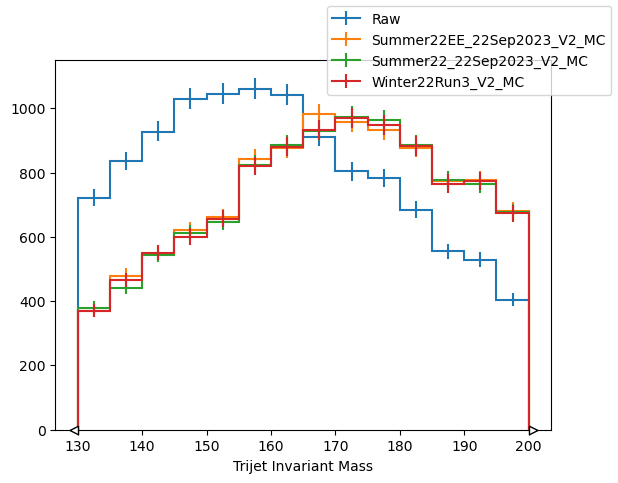

In [27]:
hd250 = hist[["Raw","Summer22EE_22Sep2023_V2_MC","Summer22_22Sep2023_V2_MC","Winter22Run3_V2_MC"],150:500:25j]
fig, ax = plt.subplots()
hd250.plot1d(ax=ax)
# ax.set_yscale("log")
fig.legend()

In [ ]:
plt.hist(
    (uncorr_b + uncorr_j1 + uncorr_j2).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="blue",
    label="uncorr",
         )
plt.hist(
    (corr_b + corr_j1 + corr_j2).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="red",
    label="corr_puppi",
         )
plt.hist(
    (corr_b_chs_2 + corr_j1_chs_2 + corr_j2_chs_2).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="purple",
    label="corr_chs",
         )
plt.hist(
    (corr_b_clus + corr_j1_clus + corr_j2_clus).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="green",
    label="corr_clus",
         )

plt.legend()

NameError: name 'uncorr_b' is not defined

In [12]:
plt.hist(
    (uncorr_b + uncorr_j1 + uncorr_j2).m.compute(),
    bins=40,
    range=(135,225),
    histtype="step",
    color="blue",
    label="uncorr",
         )
plt.hist(
    (corr_b + corr_j1 + corr_j2).m.compute(),
    bins=40,
    range=(135,225),
    histtype="step",
    color="red",
    label="corr_puppi",
         )
plt.hist(
    (corr_b_chs + corr_j1_chs + corr_j2_chs).m.compute(),
    bins=40,
    range=(135,225),
    histtype="step",
    color="purple",
    label="corr_chs",
         )
plt.hist(
    (corr_b_pr + corr_j1_pr + corr_j2_pr).m.compute(),
    bins=40,
    range=(135,225),
    histtype="step",
    color="yellow",
    label="corr_puppi_pnr",
         )
plt.hist(
    (corr_b_prn + corr_j1_prn + corr_j2_prn).m.compute(),
    bins=40,
    range=(135,225),
    histtype="step",
    color="orange",
    label="corr_puppi_pnrpn",
         )
plt.hist(
    (truth_b1 + jet1 + jet2).m.compute(),
    bins=40,
    range=(135,225),
    histtype="step",
    color="green",
    label="truth",
         )

plt.legend()

: 

In [28]:
arr = []
for truth_jet in [jet1,jet2,jet3,jet4,truth_b1,truth_b2]:
    temp_cand = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(truth_jet.delta_r(good_events.ScoutingJet),axis=1)
        ].pt
    temp_truth = truth_jet.pt
    arr.append(np.array(ak.flatten((temp_cand - temp_truth).compute())))

print(arr)

arr_corr = []
for truth_jet in [jet1,jet2,jet3,jet4,truth_b1,truth_b2]:
    temp_cand = good_events.ScoutingJets_corr[
        ak.local_index(good_events.ScoutingJets_corr,axis=1)
        == ak.argmin(truth_jet.delta_r(good_events.ScoutingJets_corr),axis=1)
        ].pt
    temp_truth = truth_jet.pt
    arr_corr.append(np.array(ak.flatten((temp_cand - temp_truth).compute())))

arr_corr

IndexError: cannot slice ListArray (of length 19765) with array(1): index out of range while attempting to get index 1 (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-37/awkward-cpp/src/cpu-kernels/awkward_ListArray_getitem_next_at.cpp#L21)

This error occurred while attempting to slice

    <GenParticleArray [[{genPartIdxMother: 42, ...}], ...] type='19765 * op...'>

with

    (:, 1)

Text(0.5, 0, 'GenJet_pT - matched_ScoutingJet_pT')

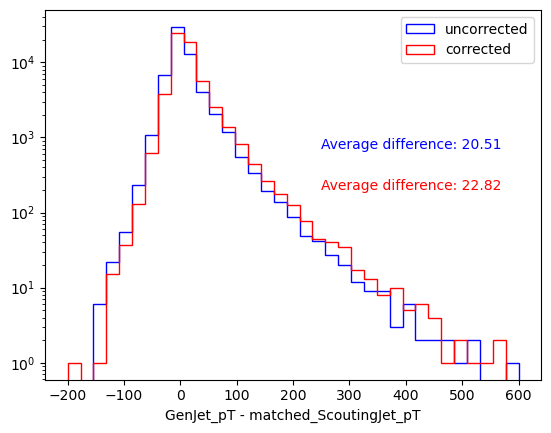

In [49]:
plt.hist(
    np.concatenate(arr),
    bins=35,
    range=(-200,600),
    histtype="step",
    color="blue",
    label="uncorrected",
         )
plt.hist(
    np.concatenate(arr_corr),
    bins=35,
    range=(-200,600),
    histtype="step",
    color="red",
    label="corrected",
         )

plt.legend()
plt.yscale("log")
plt.text(250,700,"Average difference: " + str(round(sum(abs(np.concatenate(arr)))/len(np.concatenate(arr)),2)),color="blue")
plt.text(250,200,"Average difference: " + str(round(sum(abs(np.concatenate(arr_corr)))/len(np.concatenate(arr_corr)),2)),color="red")
plt.xlabel("GenJet_pT - matched_ScoutingJet_pT")

Text(0.5, 0, 'abs(matched_ScoutingJet_pT/GenJet_pT - 1)')

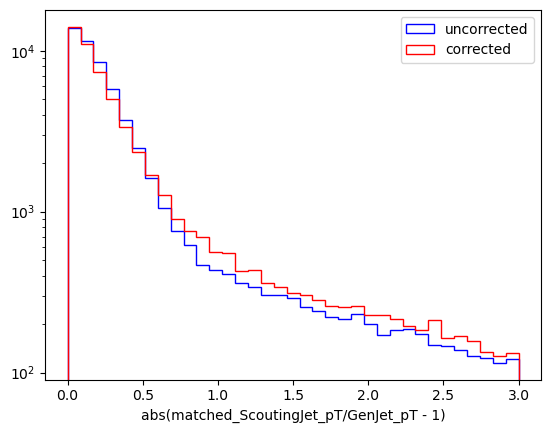

In [28]:
plt.hist(
    abs(np.concatenate(arr) - 1),
    bins=35,
    range=(0,3),
    histtype="step",
    color="blue",
    label="uncorrected",
         )
plt.hist(
    abs(np.concatenate(arr_corr) - 1),
    bins=35,
    range=(0,3),
    histtype="step",
    color="red",
    label="corrected",
         )

plt.legend()
plt.yscale("log")
plt.xlabel("abs(matched_ScoutingJet_pT/GenJet_pT - 1)")

In [21]:
exam = np.array([4,5,3,4,5])


In [24]:
sum(abs(np.concatenate(arr) - 1))

48803.395416677

In [25]:
sum(abs(np.concatenate(arr_corr) - 1))

57509.15446227789